In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering, KMeans

In [2]:
data = pd.read_csv("Iris.csv")
df=data.copy()

In [3]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.shape

(150, 6)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [6]:
df['Species'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [25]:
df.isnull().sum()

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [28]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SepalLengthCm,150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
SepalWidthCm,150.0,3.054000,0.433594,2.0,2.8,3.00,3.3,4.4
PetalLengthCm,150.0,3.758667,1.764420,1.0,1.6,4.35,5.1,6.9
PetalWidthCm,150.0,1.198667,0.763161,0.1,0.3,1.30,1.8,2.5


In [ ]:
df= df.drop('Id',axis=1)

In [13]:
df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [15]:
#separating features and label

X = df.drop('Species',axis=1)
y= df['Species']

In [16]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [17]:
# checking optimal number of cluster for KMeans based on elbow method, then visualizing up to 10 clusters, to see which one is optimal
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

#creating empty list
wcss = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k,random_state= 69)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)


C:\Users\yusuf\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\yusuf\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\yusuf\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\yusuf\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

In [19]:
print(wcss)

[600.0, 223.73200573676348, 141.15417813388652, 129.16665743082785, 102.34169540984135, 88.39219915836244, 71.94273046782051, 64.15414065643, 57.93226174593361, 48.457154791444886]


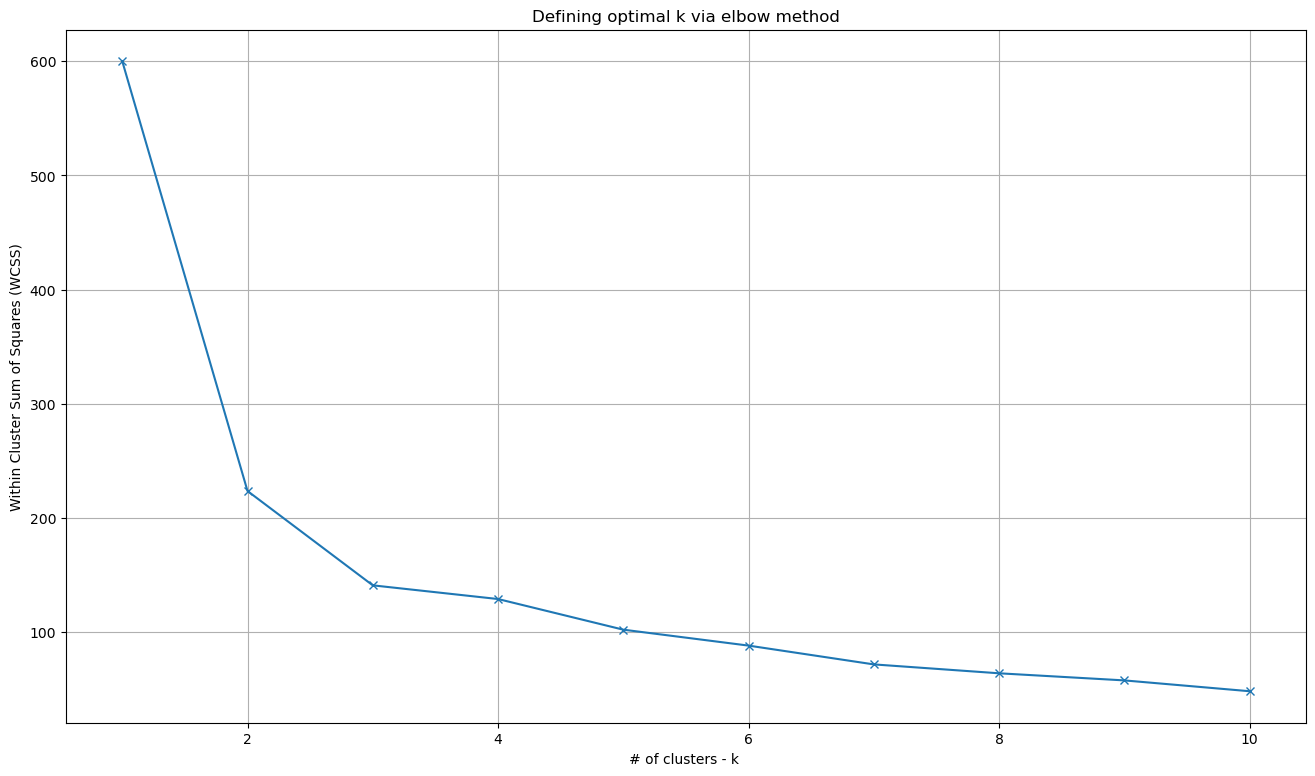

In [24]:
plt.figure(figsize=(16,9))
plt.plot(range(1,11),wcss,marker='x')
plt.xlabel('# of clusters - k ')
plt.ylabel('Within Cluster Sum of Squares (WCSS)')
plt.title('Defining optimal k via elbow method')
plt.grid()
plt.show()

In [29]:
#so, k should be 3. LETS GO
#no need for PCA, there are limted number of variables anyway

k_means = KMeans(n_clusters=3,random_state=69)
k_means_pred =k_means.fit_predict(X_scaled)
k_means_pred #will be array


C:\Users\yusuf\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 2, 2, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2,
       1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 2, 2, 2, 1, 2, 1, 2,
       2, 1, 2, 1, 1, 2, 2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 1, 1, 2, 2, 2, 2,
       2, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 1], dtype=int32)

In [31]:
df['K_Means_Clusters'] = k_means_pred

In [32]:
#trying to find to which species 0,1,2 are mostly corresponding
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,K_Means_Clusters
0,5.1,3.5,1.4,0.2,Iris-setosa,0
1,4.9,3.0,1.4,0.2,Iris-setosa,0
2,4.7,3.2,1.3,0.2,Iris-setosa,0
3,4.6,3.1,1.5,0.2,Iris-setosa,0
4,5.0,3.6,1.4,0.2,Iris-setosa,0


In [33]:
df.tail()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,K_Means_Clusters
145,6.7,3.0,5.2,2.3,Iris-virginica,2
146,6.3,2.5,5.0,1.9,Iris-virginica,1
147,6.5,3.0,5.2,2.0,Iris-virginica,2
148,6.2,3.4,5.4,2.3,Iris-virginica,2
149,5.9,3.0,5.1,1.8,Iris-virginica,1


In [35]:
df[df['K_Means_Clusters'] == 1]

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,K_Means_Clusters
53,5.5,2.3,4.0,1.3,Iris-versicolor,1
54,6.5,2.8,4.6,1.5,Iris-versicolor,1
55,5.7,2.8,4.5,1.3,Iris-versicolor,1
57,4.9,2.4,3.3,1.0,Iris-versicolor,1
58,6.6,2.9,4.6,1.3,Iris-versicolor,1
59,5.2,2.7,3.9,1.4,Iris-versicolor,1
60,5.0,2.0,3.5,1.0,Iris-versicolor,1
61,5.9,3.0,4.2,1.5,Iris-versicolor,1
62,6.0,2.2,4.0,1.0,Iris-versicolor,1
63,6.1,2.9,4.7,1.4,Iris-versicolor,1


In [36]:
df[df['K_Means_Clusters'] == 2]

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,K_Means_Clusters
50,7.0,3.2,4.7,1.4,Iris-versicolor,2
51,6.4,3.2,4.5,1.5,Iris-versicolor,2
52,6.9,3.1,4.9,1.5,Iris-versicolor,2
56,6.3,3.3,4.7,1.6,Iris-versicolor,2
65,6.7,3.1,4.4,1.4,Iris-versicolor,2
70,5.9,3.2,4.8,1.8,Iris-versicolor,2
75,6.6,3.0,4.4,1.4,Iris-versicolor,2
76,6.8,2.8,4.8,1.4,Iris-versicolor,2
77,6.7,3.0,5.0,1.7,Iris-versicolor,2
85,6.0,3.4,4.5,1.6,Iris-versicolor,2


In [37]:
df['K_Means_Clusters'].replace({0:'Iris-setosa', 1:'Iris-versicolor',2:'Iris-virginica'},inplace=True)

C:\Users\yusuf\AppData\Local\Temp\ipykernel_18648\3507832090.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['K_Means_Clusters'].replace({0:'Iris-setosa', 1:'Iris-versicolor',2:'Iris-virginica'},inplace=True)


In [38]:
#visualizing KMeans results
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,K_Means_Clusters
0,5.1,3.5,1.4,0.2,Iris-setosa,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa,Iris-setosa


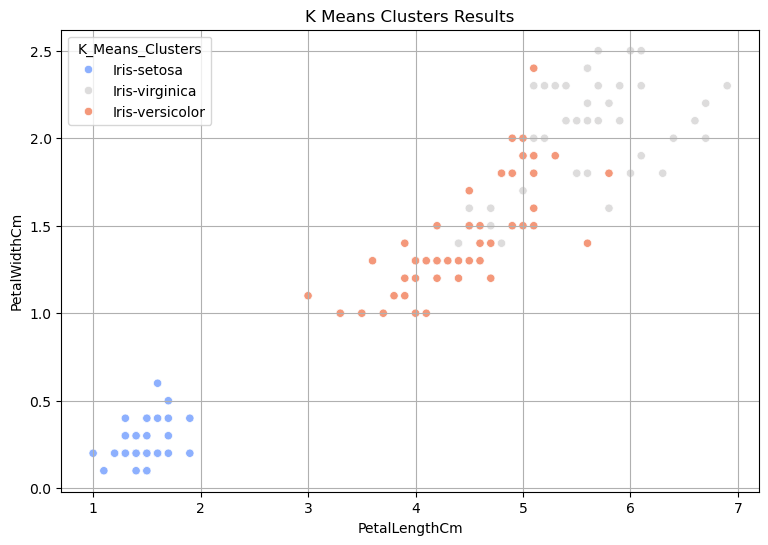

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9,6),dpi=100)
sns.scatterplot(data=df,x='PetalLengthCm',y='PetalWidthCm',hue='K_Means_Clusters',palette='coolwarm')
plt.title('K Means Clusters Results')
plt.grid()

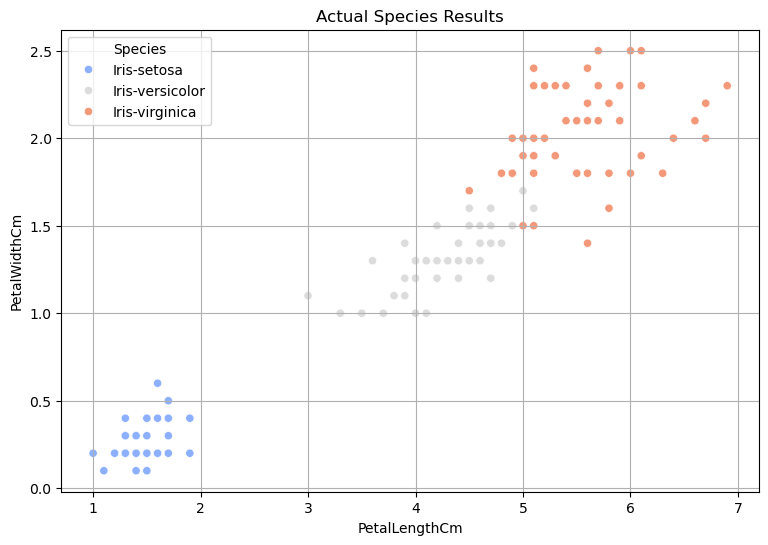

In [43]:
#Visualizing actual data to compare with K means

plt.figure(figsize=(9,6),dpi=100)
sns.scatterplot(data=df,x='PetalLengthCm',y='PetalWidthCm',hue='Species',palette='coolwarm')
plt.title('Actual Species Results')
plt.grid()

In [50]:
df['Species'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [45]:



df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,K_Means_Clusters
0,5.1,3.5,1.4,0.2,Iris-setosa,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa,Iris-setosa


In [78]:
#how much percentage Kmeans visualized correctly?

from sklearn.metrics import accuracy_score

kmeans_accuracy = accuracy_score(df['Species'],df['K_Means_Clusters'])
kmeans_accuracy

0.8133333333333334

In [49]:
from sklearn.metrics import confusion_matrix

matrix = confusion_matrix(df['Species'],df['K_Means_Clusters'])
matrix

array([[50,  0,  0],
       [ 0, 39, 11],
       [ 0, 17, 33]])

In [ ]:
#Zero mistake for Iris-Setosa !

In [ ]:
#Lets move to Hierarchical Clustering Method

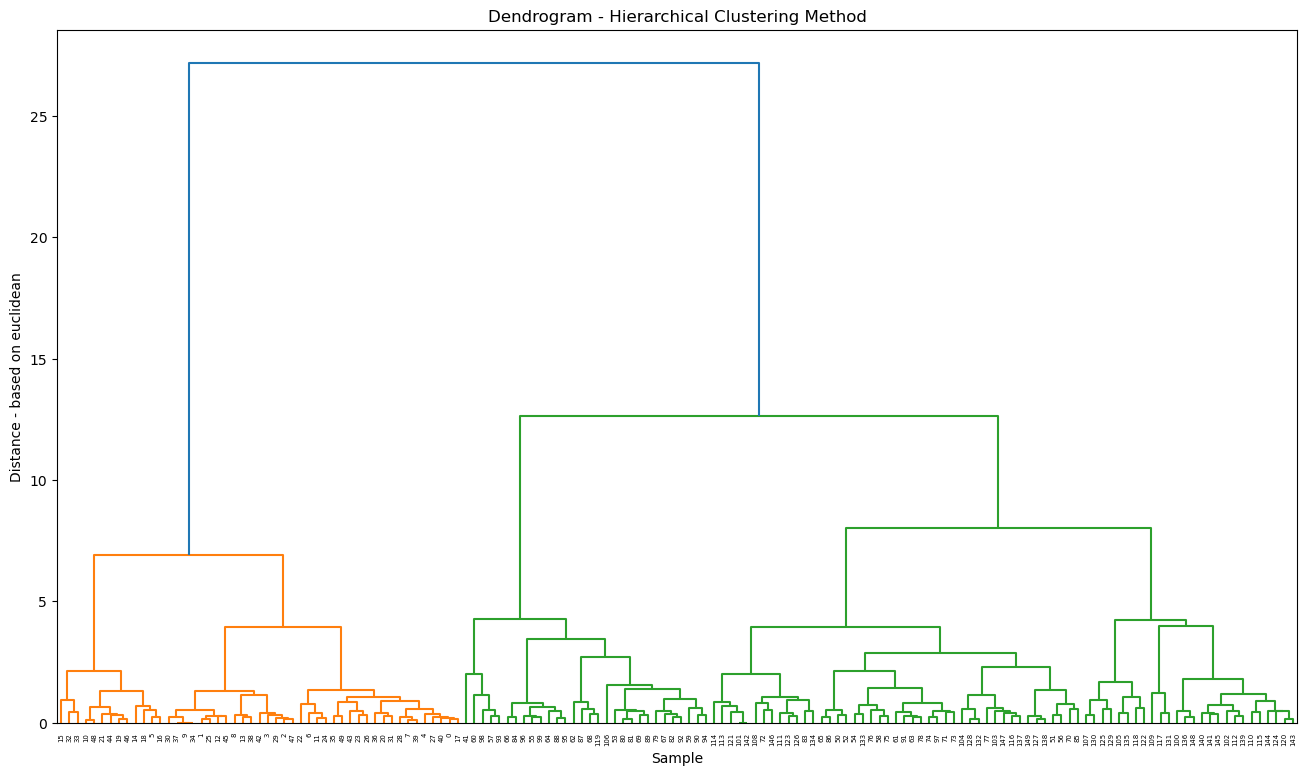

In [54]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

plt.figure(figsize=(16,9))

dendrogram(linkage(X_scaled,method='ward',metric='euclidean'))

plt.title('Dendrogram - Hierarchical Clustering Method')
plt.xlabel('Sample')
plt.ylabel('Distance - based on euclidean')

plt.show()

In [55]:
from sklearn.cluster import AgglomerativeClustering
hc= AgglomerativeClustering(n_clusters=3,metric='euclidean',linkage='ward')
hc_pred=hc.fit_predict(X_scaled)
hc_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 2, 0, 2, 0, 2, 0, 2, 2, 0, 2, 0, 2, 0,
       2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 0, 2, 0, 0, 2,
       2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 2, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [57]:
df['HC_Clusters'] = hc_pred
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,K_Means_Clusters,HC_Clusters
0,5.1,3.5,1.4,0.2,Iris-setosa,Iris-setosa,1
1,4.9,3.0,1.4,0.2,Iris-setosa,Iris-setosa,1
2,4.7,3.2,1.3,0.2,Iris-setosa,Iris-setosa,1
3,4.6,3.1,1.5,0.2,Iris-setosa,Iris-setosa,1
4,5.0,3.6,1.4,0.2,Iris-setosa,Iris-setosa,1


In [69]:
df[df['HC_Clusters']==0]['Species'].value_counts()

Species
Iris-virginica     48
Iris-versicolor    23
Name: count, dtype: int64

In [70]:
df[df['HC_Clusters']==1]['Species'].value_counts()

Species
Iris-setosa    49
Name: count, dtype: int64

In [71]:
df[df['HC_Clusters']==2]['Species'].value_counts()

Species
Iris-versicolor    27
Iris-virginica      2
Iris-setosa         1
Name: count, dtype: int64

In [72]:
df['HC_Clusters'].replace({0:'Iris-virginica', 1:'Iris-setosa',2:'Iris-versicolor'},inplace=True)

C:\Users\yusuf\AppData\Local\Temp\ipykernel_18648\3699073431.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['HC_Clusters'].replace({0:'Iris-virginica', 1:'Iris-setosa',2:'Iris-versicolor'},inplace=True)


In [73]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,K_Means_Clusters,HC_Clusters
0,5.1,3.5,1.4,0.2,Iris-setosa,Iris-setosa,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa,Iris-setosa,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa,Iris-setosa,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa,Iris-setosa,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa,Iris-setosa,Iris-setosa


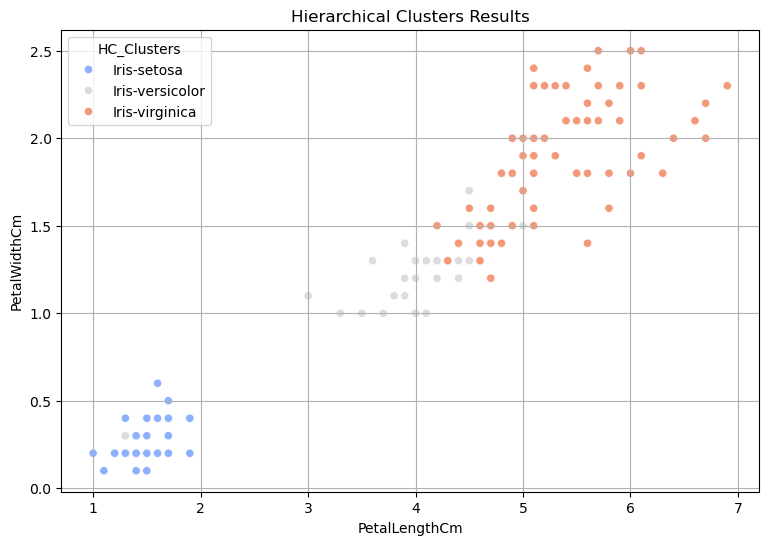

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9,6),dpi=100)
sns.scatterplot(data=df,x='PetalLengthCm',y='PetalWidthCm',hue='HC_Clusters',palette='coolwarm')
plt.title('Hierarchical Clusters Results')
plt.grid()

In [79]:
#how much percentage HC visualized correctly?

from sklearn.metrics import accuracy_score

hc_accuracy = accuracy_score(df['Species'],df['HC_Clusters'])
hc_accuracy

0.8266666666666667

In [77]:
from sklearn.metrics import confusion_matrix

matrix = confusion_matrix(df['Species'],df['HC_Clusters'])
matrix

array([[49,  1,  0],
       [ 0, 27, 23],
       [ 0,  2, 48]])

In [80]:
print("KMeans Accuracy:", kmeans_accuracy)
print("Hierarchical Accuracy:", hc_accuracy)

KMeans Accuracy: 0.8133333333333334
Hierarchical Accuracy: 0.8266666666666667


In [ ]:
#Iris setosa -> very easy to distringuish
# Other 2 (Iris-versicolor and Iris-virginica) are overlapping sometimes.
#it leads to misclassification

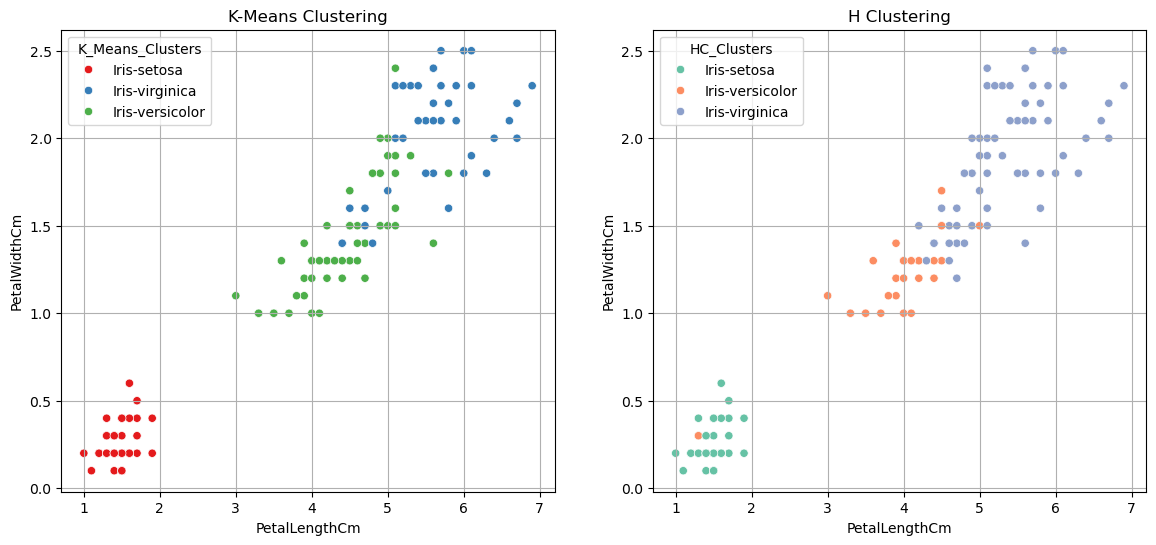

In [82]:
# side by side visualization

import matplotlib.pyplot as plt
import seaborn as sns
#the below code is what is different between 1 vs. side by side visualization
fig,axes = plt.subplots(1,2, figsize=(14,6))


# we don't need this: plt.figure(figsize=(9,6),dpi=100)
#adding one thing more which is ax=axes[0] and palette changing to Set_1
sns.scatterplot(ax=axes[0],data=df,x='PetalLengthCm',y='PetalWidthCm',hue='K_Means_Clusters',palette='Set1')
#we don't need this plt.title('K Means Clusters Results')
#plt.grid()
axes[0].set_title('K-Means Clustering')
axes[0].grid()

#same for HC
sns.scatterplot(ax=axes[1],data=df,x='PetalLengthCm',y='PetalWidthCm',hue='HC_Clusters',palette='Set2')

axes[1].set_title('H Clustering')
axes[1].grid()